# OSC PD Controller — Benchmark Analysis

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

RESULTS = Path("results")

def load_latest(prefix: str) -> dict:
    files = sorted(RESULTS.glob(f"{prefix}_*.npz"))
    assert files, f"No results found for '{prefix}' in {RESULTS}"
    path = files[-1]
    print(f"Loading: {path.name}")
    raw = np.load(path, allow_pickle=True)
    return {k: raw[k] for k in raw.files}

def t0(ts): return ts - ts[0]

---
## 1 — Step response

Loading: step_response_20260526_164031.npz


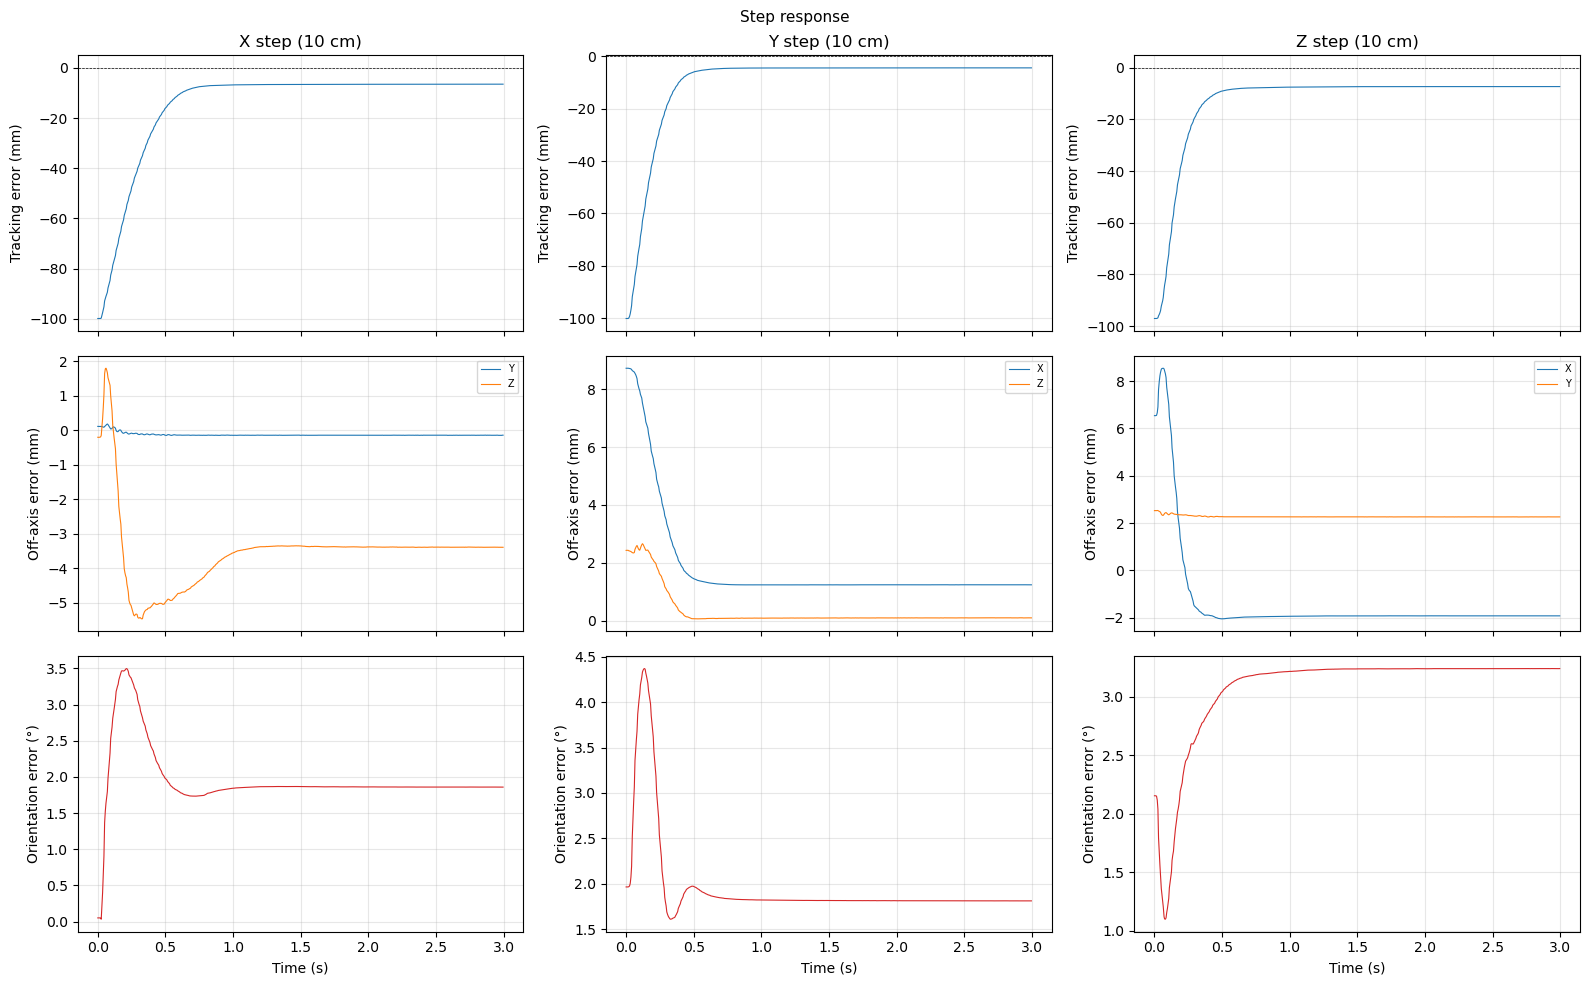

In [4]:
sr = load_latest("step_response")
home_pos = sr["home_position"]
step_m = float(sr["step_m"])
AXES = ["x", "y", "z"]
LABELS = ["X", "Y", "Z"]

# --- unpack nested arrays saved with object dtype
def get(data, key, axis):
    arr = data[f"{axis}/{key}"] if f"{axis}/{key}" in data else data[axis].item()[key]
    return arr

# Simpler flat access (step_response.py saves data[axis_name] as sub-dict via np.savez)
# np.savez flattens nested dicts with '/' separator when keys are dicts — 
# since we save data[axis_name] = dict, it's stored as an object array. Unpack:
def unpack(sr, axis):
    obj = sr[axis].item()  # recover the dict
    return obj

fig, axes_plots = plt.subplots(3, 3, figsize=(16, 10), sharex="col")

for col, (ax_name, ax_label, ax_idx) in enumerate(zip(AXES, LABELS, [0,1,2])):
    d = unpack(sr, ax_name)
    ts = t0(d["ts"])
    pos = d["position"]
    ori = np.degrees(d["ori_err_rad"])
    target = d["target"]

    # Position along step axis
    axes_plots[0, col].plot(ts, (pos[:, ax_idx] - target[ax_idx]) * 1e3, lw=0.8, label="error")
    axes_plots[0, col].axhline(0, color="k", lw=0.5, ls="--")
    axes_plots[0, col].set(title=f"{ax_label} step ({step_m*100:.0f} cm)", ylabel="Tracking error (mm)")
    axes_plots[0, col].grid(True, alpha=0.3)

    # Off-axis position errors
    for off_idx, off_label in [(i, l) for i, l in enumerate(LABELS) if i != ax_idx]:
        axes_plots[1, col].plot(ts, (pos[:, off_idx] - home_pos[off_idx]) * 1e3, lw=0.8, label=off_label)
    axes_plots[1, col].set(ylabel="Off-axis error (mm)")
    axes_plots[1, col].legend(fontsize=7)
    axes_plots[1, col].grid(True, alpha=0.3)

    # Orientation error
    axes_plots[2, col].plot(ts, ori, lw=0.8, color="tab:red")
    axes_plots[2, col].set(xlabel="Time (s)", ylabel="Orientation error (°)")
    axes_plots[2, col].grid(True, alpha=0.3)

plt.suptitle("Step response", fontsize=11)
plt.tight_layout()
plt.show()

---
## 2 — Feedforward injection

Loading: feedforward_injection_20260528_111733.npz


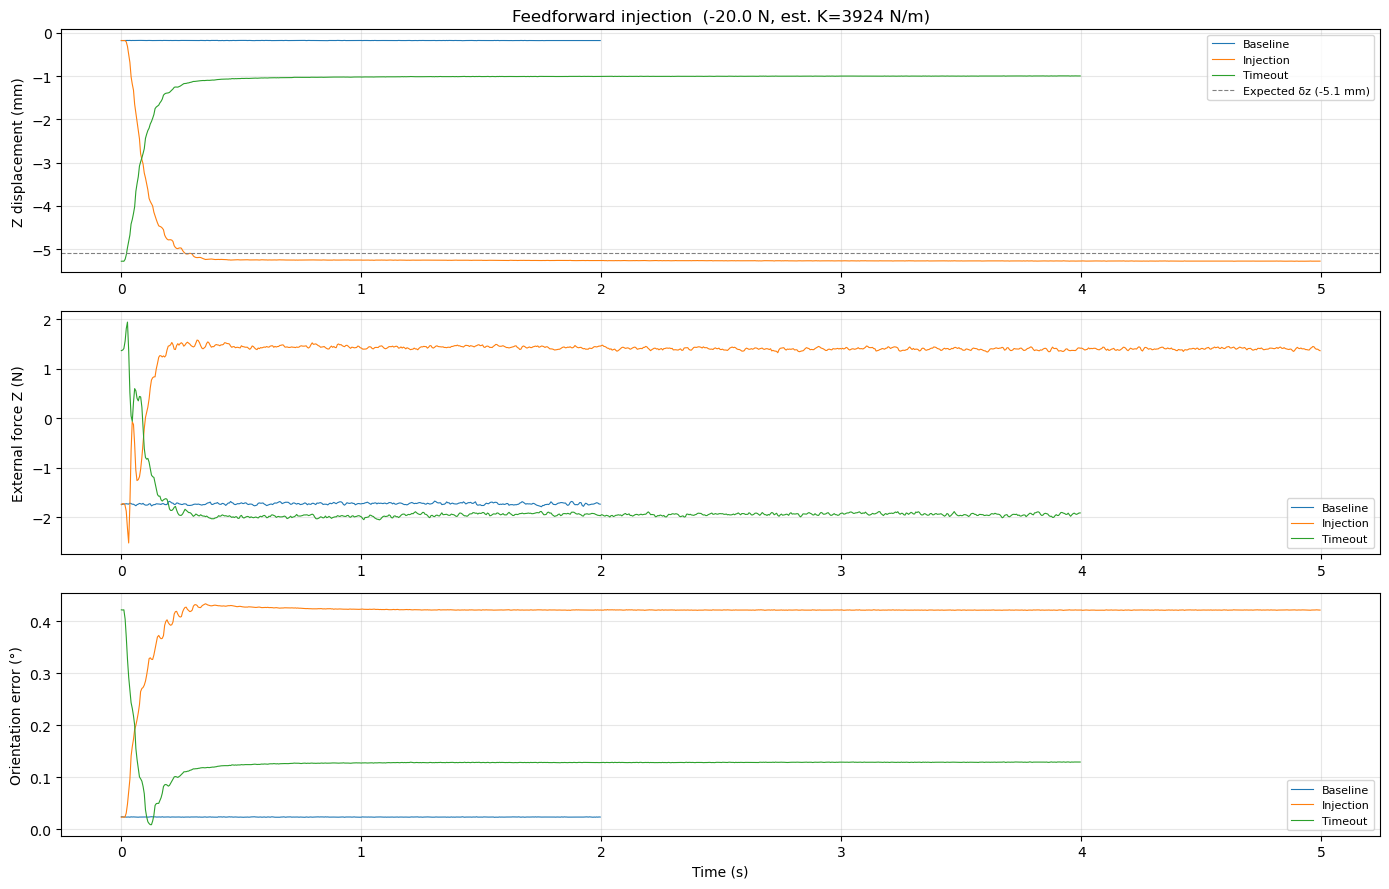

Estimated stiffness K_z: 3924 N/m


In [17]:
ff = load_latest("feedforward_injection")
home_pos_ff = ff["home_position"]
ff_force = float(ff["ff_force_n"])
delta_z = float(ff["delta_z_m"])
k_est = float(ff["k_estimated"])

baseline = ff["baseline"].item()
inject   = ff["inject"].item()
timeout  = ff["timeout"].item()

# Stitch phases together for plotting
phases = [("Baseline", baseline), ("Injection", inject), ("Timeout", timeout)]
colors = ["tab:blue", "tab:orange", "tab:green"]

fig, axes_ff = plt.subplots(3, 1, figsize=(14, 9), sharex=False)

for (label, d), color in zip(phases, colors):
    ts = t0(d["ts"])
    axes_ff[0].plot(ts, (d["position"][:, 2] - home_pos_ff[2]) * 1e3, lw=0.8, label=label, color=color)
    axes_ff[1].plot(ts, d["force"][:, 2], lw=0.8, label=label, color=color)
    axes_ff[2].plot(ts, np.degrees(d["ori_err_rad"]), lw=0.8, label=label, color=color)

axes_ff[0].axhline(delta_z * 1e3, ls="--", color="gray", lw=0.8, label=f"Expected δz ({delta_z*1e3:.1f} mm)")
axes_ff[0].set(ylabel="Z displacement (mm)", title=f"Feedforward injection  ({ff_force} N, est. K={k_est:.0f} N/m)")
axes_ff[1].set(ylabel="External force Z (N)")
axes_ff[2].set(ylabel="Orientation error (°)", xlabel="Time (s)")
for ax in axes_ff:
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Estimated stiffness K_z: {k_est:.0f} N/m")

---
## 3 — Nullspace drift

In [ ]:
nd = load_latest("nullspace_drift")
hold_s = float(nd["hold_s"])
JOINT_LABELS = [f"J{i+1}" for i in range(7)]

trials = [
    ("No damping", "no_damping", "tab:orange"),
    ("Damping=5.0", "damping", "tab:blue"),
]

fig, axes_nd = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

for label, prefix, color in trials:
    q = nd[f"{prefix}_q"]           # (N, 7)
    q0 = nd[f"{prefix}_q0"]         # (7,)
    ts = t0(nd[f"{prefix}_ts"])
    pos = nd[f"{prefix}_position"]
    ori = np.degrees(nd[f"{prefix}_ori_err_rad"])

    drift = np.degrees(q - q0)      # joint drift in degrees

    # RMS drift across joints
    axes_nd[0].plot(ts, np.sqrt((drift**2).mean(axis=1)), lw=0.8, label=label, color=color)

    # TCP position error
    home_pos_nd = nd[f"{prefix}_home_position"]
    tcp_err = np.linalg.norm(pos - home_pos_nd, axis=1) * 1e3
    axes_nd[1].plot(ts, tcp_err, lw=0.8, label=label, color=color)

    # Orientation error
    axes_nd[2].plot(ts, ori, lw=0.8, label=label, color=color)

axes_nd[0].set(ylabel="Joint drift RMS (°)", title=f"Nullspace drift over {hold_s:.0f} s hold")
axes_nd[1].set(ylabel="TCP position error (mm)")
axes_nd[2].set(ylabel="Orientation error (°)", xlabel="Time (s)")
for ax in axes_nd:
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Per-joint drift table
print("Final joint drift (degrees):")
print(f"{'Joint':<8}", end="")
for label, prefix, _ in trials:
    print(f"{label:>18}", end="")
print()
for j in range(7):
    print(f"J{j+1:<7}", end="")
    for _, prefix, _ in trials:
        q_final = nd[f"{prefix}_q"][-1]
        q0 = nd[f"{prefix}_q0"]
        print(f"{np.degrees(q_final[j] - q0[j]):>+18.2f}", end="")
    print()

---
## 4 — Stiffness characterization

In [ ]:
sc = load_latest("stiffness")
home_pos_sc = sc["home_position"]
AXES = [("x", 0), ("y", 1), ("z", 2)]

fig, axes_sc = plt.subplots(len(AXES), 2, figsize=(14, 10))

for row, (ax_name, ax_idx) in enumerate(AXES):
    d = sc[ax_name].item()
    ts = t0(d["ts"])
    pos = d["position"]
    force = d["force"]
    k_est = float(d["k_estimated"])
    delta_x = (pos[:, ax_idx] - home_pos_sc[ax_idx]) * 1e3
    f_axis = force[:, ax_idx]

    # Time series
    ax_ts = axes_sc[row, 0]
    ax_ts2 = ax_ts.twinx()
    ax_ts.plot(ts, delta_x, lw=0.8, color="tab:blue", label="Displacement")
    ax_ts2.plot(ts, f_axis, lw=0.8, color="tab:orange", label="Force")
    ax_ts.set(ylabel=f"δ{ax_name.upper()} (mm)", title=f"{ax_name.upper()} axis — time series")
    ax_ts2.set_ylabel("Force (N)", color="tab:orange")
    ax_ts.grid(True, alpha=0.3)

    # Force vs displacement scatter
    ax_fv = axes_sc[row, 1]
    mask = np.abs(f_axis) > 0.5
    ax_fv.scatter(delta_x[mask], f_axis[mask], s=2, alpha=0.4, color="tab:blue")
    if not np.isnan(k_est):
        xlim = np.array([delta_x[mask].min(), delta_x[mask].max()])
        ax_fv.plot(xlim, -k_est * xlim / 1e3, color="tab:red", lw=1.5,
                   label=f"Fit: K={k_est:.0f} N/m")
    ax_fv.set(xlabel=f"δ{ax_name.upper()} (mm)", ylabel="Force (N)",
               title=f"{ax_name.upper()} stiffness")
    ax_fv.legend(fontsize=8)
    ax_fv.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nEstimated stiffness:")
for ax_name, ax_idx in AXES:
    k = float(sc[ax_name].item()["k_estimated"])
    print(f"  K_{ax_name}: {k:.0f} N/m")

---
## 5 — Trajectory tracking: Fast ramp Z (gain tuning)

Loads the latest `trajectory_tracking_rim_controller_*.npz`.
The `ramp_z` test commands a 5 cm move at ~0.30 m/s — matching the peak velocity of a rapid
haptic-device push — to reproduce the Ry orientation oscillation seen during RIM teleoperation.

**Tuning loop**: edit `rim_controller.yaml` → re-run `trajectory_tracking.py` → re-run this cell.
Watch Ry transient RMS as the figure of merit.

In [ ]:
from scipy.spatial.transform import Rotation

tt = load_latest("trajectory_tracking_rim_controller")
ramp = tt["ramp_z"].item()

ts_r   = t0(ramp["ts"])
pos    = ramp["position"]           # (N, 3)
cmd    = ramp["cmd_position"]       # (N, 3)
euler  = ramp["euler_deg"]          # (N, 3) Rx/Ry/Rz vs home
geo    = np.degrees(ramp["ori_err_rad"])  # geodesic

RATE_HZ = 1.0 / float(np.median(np.diff(ramp["ts"])))
freqs   = np.fft.rfftfreq(len(geo), d=1.0 / RATE_HZ)

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=False)

# — Z position tracking
ax = axes[0]
ax.plot(ts_r, cmd[:, 2] * 1e3, lw=1.0, ls="--", color="gray", label="Command")
ax.plot(ts_r, pos[:, 2] * 1e3, lw=0.9, color="tab:blue", label="Actual TCP z")
ax.set(ylabel="Z position (mm)", title=f"Fast ramp Z — position tracking  (config: {tt['config']})")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# — Per-axis orientation error over time
ax = axes[1]
COLORS = ["tab:blue", "tab:orange", "tab:red"]
LABELS = ["Rx", "Ry  ← cross-coupling axis", "Rz (wrist)"]
for i, (lbl, col) in enumerate(zip(LABELS, COLORS)):
    ax.plot(ts_r, euler[:, i], lw=0.8, color=col, label=lbl, alpha=0.9)
ax.plot(ts_r, geo, lw=1.0, color="k", ls="--", label="Geodesic", alpha=0.5)
ax.axhline(0, color="k", lw=0.4, ls=":")
ax.set(ylabel="Error (deg)", title="Orientation error vs home")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# — Frequency spectrum (Ry dominant)
ax = axes[2]
for i, (lbl, col) in enumerate(zip(LABELS, COLORS)):
    sig  = euler[:, i] - euler[:, i].mean()
    spec = np.abs(np.fft.rfft(sig)) * 2 / len(sig)
    ax.semilogy(freqs, spec, lw=0.7, color=col, alpha=0.85, label=lbl)
ax.set(xlabel="Frequency (Hz)", ylabel="Amplitude (deg, peak)", title="Orientation error spectrum")
ax.set_xlim(0, min(RATE_HZ / 2, 30))
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# — Summary
n = len(euler)
n_ramp = int(np.argmax(cmd[:, 2] >= cmd[:, 2].max() - 1e-4))  # first sample at target
ss_start = n - int(0.5 * RATE_HZ)

print("Orientation error summary:")
for i, lbl in enumerate(["Rx", "Ry", "Rz"]):
    rms_t  = float(np.std(euler[:n_ramp, i]))
    rms_ss = float(np.std(euler[ss_start:, i]))
    peak   = float(np.abs(euler[:, i]).max())
    sig    = euler[:, i] - euler[:, i].mean()
    spec   = np.abs(np.fft.rfft(sig)) * 2 / len(sig)
    dom_f  = float(freqs[int(np.argmax(spec[1:])) + 1])
    dom_a  = float(spec[int(np.argmax(spec[1:])) + 1])
    print(f"  {lbl}: transient RMS={rms_t:.2f}°  SS RMS={rms_ss:.2f}°  peak={peak:.2f}°  dominant={dom_f:.1f} Hz ({dom_a:.2f}° pk)")
print(f"\nZ tracking SS error: {abs(pos[ss_start:, 2].mean() - cmd[-1, 2]) * 1e3:.2f} mm")